<a href="https://colab.research.google.com/github/kishan009-code/Placement_Prediction_Model/blob/main/placement_prediction_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
import numpy as np
import pandas as pd
df=pd.read_csv('/content/placement.csv')
df.head()


,Unnamed: 0,cgpa,iq,placement
0,0,6.8,123.0,1
1,1,5.9,106.0,0
2,2,5.3,121.0,0
3,3,7.4,132.0,1
4,4,5.8,142.0,0


In [7]:
df=df.iloc[:,1:]

In [8]:
x=df.iloc[:,0:2]
y=df.iloc[:,-1]

In [9]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=(train_test_split(x,y,test_size=0.1))

In [10]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
x_train=scaler.fit_transform(x_train)

In [11]:
x_test=scaler.transform(x_test)

In [12]:
from sklearn.linear_model import LogisticRegression
clf=LogisticRegression()

In [14]:
# model traning
clf.fit(x_train,y_train)

LogisticRegression()

In [16]:
# prediction
y_pred=clf.predict(x_test)
y_pred

array([1, 1, 0, 0, 0, 0, 1, 1, 1, 0])

In [17]:
y_test

,placement
90,1
66,1
68,0
40,0
87,1
45,1
32,1
57,1
21,1
85,1


In [18]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_pred)

0.7

<Axes: >

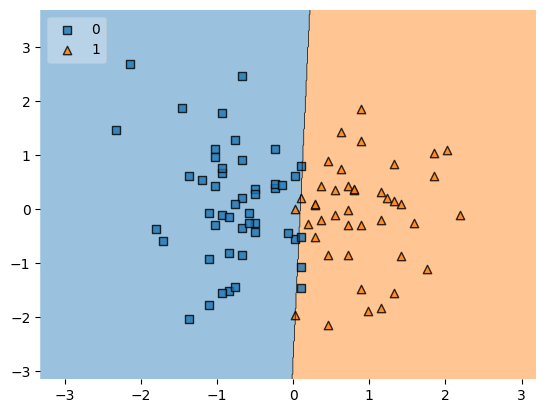

In [19]:
from mlxtend.plotting import plot_decision_regions
plot_decision_regions(x_train,y_train.values,clf=clf,legend=2)

In [22]:
import pickle
pickle.dump(clf,open('model.pkl','wb'))